In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [47]:
url = url = "https://odn.data.socrata.com/resource/8apn-rhyh.csv?$limit=500000"

main_df = pd.read_csv(url)

print(main_df.head())

                 id                             name    type  year  \
0  1600000US3106820        Bruning village, Nebraska   place  2013   
1  1600000US2280815         Westlake city, Louisiana   place  2013   
2  1600000US5147352           Low Moor CDP, Virginia   place  2013   
3  1600000US1902395             Aplington city, Iowa   place  2013   
4    0500000US72001  Adjuntas Municipio, Puerto Rico  county  2013   

                                       variable   value  
0   percent_high_school_graduate_or_higher_rank  1696.0  
1  male_percent_graduate_or_professional_degree     2.0  
2              male_percent_less_than_9th_grade    41.9  
3            female_percent_less_than_9th_grade     8.7  
4                   percent_less_than_9th_grade    26.8  


In [48]:
main_df

,id,name,type,year,variable,value
0,1600000US3106820,"Bruning village, Nebraska",place,2013,percent_high_school_graduate_or_higher_rank,1696.0
1,1600000US2280815,"Westlake city, Louisiana",place,2013,male_percent_graduate_or_professional_degree,2.0
2,1600000US5147352,"Low Moor CDP, Virginia",place,2013,male_percent_less_than_9th_grade,41.9
3,1600000US1902395,"Aplington city, Iowa",place,2013,female_percent_less_than_9th_grade,8.7
4,0500000US72001,"Adjuntas Municipio, Puerto Rico",county,2013,percent_less_than_9th_grade,26.8
...,...,...,...,...,...,...
499995,8600000US88343,88343 ZIP Code,zip_code,2013,percent_high_school_graduate,36.0
499996,8600000US57560,57560 ZIP Code,zip_code,2013,percent_bachelors_degree_or_higher_rank,26841.0
499997,8600000US07603,07603 ZIP Code,zip_code,2013,female_percent_high_school_graduate,38.2
499998,1600000US2703106,"Babbitt city, Minnesota",place,2013,percent_associates_degree,14.1


In [49]:
main_df_less_than_9th = main_df[main_df['variable'].str.contains("less_than_9th")]

In [50]:
main_df_less_than_9th

,id,name,type,year,variable,value
2,1600000US5147352,"Low Moor CDP, Virginia",place,2013,male_percent_less_than_9th_grade,41.9
3,1600000US1902395,"Aplington city, Iowa",place,2013,female_percent_less_than_9th_grade,8.7
4,0500000US72001,"Adjuntas Municipio, Puerto Rico",county,2013,percent_less_than_9th_grade,26.8
5,1600000US4835954,"Indian Springs CDP, Texas",place,2013,female_percent_less_than_9th_grade,12.5
10,8600000US78221,78221 ZIP Code,zip_code,2013,percent_less_than_9th_grade,17.0
...,...,...,...,...,...,...
499967,8600000US32713,32713 ZIP Code,zip_code,2013,percent_less_than_9th_grade,2.1
499969,1600000US4965240,"Rush Valley town, Utah",place,2013,percent_less_than_9th_grade,3.8
499972,8600000US98027,98027 ZIP Code,zip_code,2013,female_percent_less_than_9th_grade,1.5
499984,8600000US13841,13841 ZIP Code,zip_code,2013,male_percent_less_than_9th_grade,4.0


In [51]:
main_df_less_than_9th.describe()

,year,value
count,48437.000000,48437.000000
mean,2013.000103,5.737308
std,0.022719,7.699162
min,2013.000000,0.000000
25%,2013.000000,1.300000
50%,2013.000000,3.600000
75%,2013.000000,7.300000
max,2018.000000,100.000000


In [52]:
main_df_less_than_9th.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48437 entries, 2 to 499991
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        48437 non-null  object 
 1   name      48437 non-null  object 
 2   type      48437 non-null  object 
 3   year      48437 non-null  int64  
 4   variable  48437 non-null  object 
 5   value     48437 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 2.6+ MB


In [53]:
main_df_less_than_9th= main_df_less_than_9th.rename(columns={'value': 'less_than_9th'})

In [54]:
main_df_less_than_9th.drop(columns=['id'], inplace=True)

In [55]:
main_df_less_than_9th

,name,type,year,variable,less_than_9th
2,"Low Moor CDP, Virginia",place,2013,male_percent_less_than_9th_grade,41.9
3,"Aplington city, Iowa",place,2013,female_percent_less_than_9th_grade,8.7
4,"Adjuntas Municipio, Puerto Rico",county,2013,percent_less_than_9th_grade,26.8
5,"Indian Springs CDP, Texas",place,2013,female_percent_less_than_9th_grade,12.5
10,78221 ZIP Code,zip_code,2013,percent_less_than_9th_grade,17.0
...,...,...,...,...,...
499967,32713 ZIP Code,zip_code,2013,percent_less_than_9th_grade,2.1
499969,"Rush Valley town, Utah",place,2013,percent_less_than_9th_grade,3.8
499972,98027 ZIP Code,zip_code,2013,female_percent_less_than_9th_grade,1.5
499984,13841 ZIP Code,zip_code,2013,male_percent_less_than_9th_grade,4.0


In [56]:
main_df_less_than_9th['name'].value_counts()

name
Chesapeake city, Virginia          4
Lexington city, Virginia           4
Falls Church city, Virginia        4
59528 ZIP Code                     3
65608 ZIP Code                     3
                                  ..
52803 ZIP Code                     1
Burkesville city, Kentucky         1
Odebolt city, Iowa                 1
Voorheesville village, New York    1
Wayne County, North Carolina       1
Name: count, Length: 37657, dtype: int64

In [57]:
main_df_less_than_9th.groupby("name")["less_than_9th"].mean().reset_index()

,name,less_than_9th
0,00602 ZIP Code,27.40
1,00603 ZIP Code,23.10
2,00610 ZIP Code,25.60
3,00612 ZIP Code,18.55
4,00617 ZIP Code,22.80
...,...,...
37652,"Zumbro Falls city, Minnesota",0.00
37653,"Zumbrota city, Minnesota",4.70
37654,"Zuni Pueblo CDP, New Mexico",5.60
37655,"Zwingle city, Iowa",2.60


In [58]:
main_df_less_than_9th[main_df_less_than_9th['name']\
.map(main_df_less_than_9th['name'].value_counts()) > 2]['name'].unique()

array(['48848 ZIP Code', '31027 ZIP Code', '76888 ZIP Code',
       'Franklin CDP, Arizona', 'Kerrick city, Minnesota',
       '77090 ZIP Code', '35150 ZIP Code', '75149 ZIP Code',
       '79719 ZIP Code', 'Pekin city, Illinois', '80611 ZIP Code',
       'Weston Lakes city, Texas', '59487 ZIP Code',
       'Houston-The Woodlands-Sugar Land, TX Metro Area',
       '38052 ZIP Code', 'Jefferson County, Ohio', '81090 ZIP Code',
       'Liberty City CDP, Texas', 'Fremont County, Idaho',
       'Zeigler city, Illinois', '45773 ZIP Code',
       'Ashland CDP, California', '67853 ZIP Code',
       'Cortland, NY Micro Area', 'Calumet City city, Illinois',
       'Rocky Ridge town, Utah', 'Lyford city, Texas',
       'Cass County, Texas', 'Sallisaw city, Oklahoma', '25159 ZIP Code',
       'Rocky Point CDP, Washington', 'Grandview city, Washington',
       '66756 ZIP Code', '62469 ZIP Code', '25187 ZIP Code',
       'Cedar Grove CDP, New Mexico', '68701 ZIP Code',
       'Silver Cliff town, Colo

In [59]:
main_df_less_than_9th[
    main_df_less_than_9th["name"] == "48848 ZIP Code"
]


,name,type,year,variable,less_than_9th
39,48848 ZIP Code,zip_code,2013,percent_less_than_9th_grade,1.7
109133,48848 ZIP Code,zip_code,2013,female_percent_less_than_9th_grade,1.9
480004,48848 ZIP Code,zip_code,2013,male_percent_less_than_9th_grade,1.5


In [60]:
main_df_less_than_9th[main_df_less_than_9th['name'] == '31027 ZIP Code']

,name,type,year,variable,less_than_9th
55,31027 ZIP Code,zip_code,2013,male_percent_less_than_9th_grade,6.6
183863,31027 ZIP Code,zip_code,2013,female_percent_less_than_9th_grade,8.8
335187,31027 ZIP Code,zip_code,2013,percent_less_than_9th_grade,7.8


In [ ]:
df = main_df_less_than_9th.copy()






,name,type,year,variable,less_than_9th
0,"Adjuntas Municipio, Puerto Rico",county,2013,percent_less_than_9th_grade,26.8
1,78221 ZIP Code,zip_code,2013,percent_less_than_9th_grade,17.0
2,"Gassaway town, West Virginia",place,2013,percent_less_than_9th_grade,9.5
3,48848 ZIP Code,zip_code,2013,percent_less_than_9th_grade,1.7
4,76888 ZIP Code,zip_code,2013,percent_less_than_9th_grade,0.0


In [67]:
general = df[df["variable"] == "percent_less_than_9th_grade"]

# 2️⃣ male/female
gender = df[df["variable"].isin([
    "male_percent_less_than_9th_grade",
    "female_percent_less_than_9th_grade"
])]

In [68]:
# 3️⃣ ortalama al (diğer kolonları first ile koru)
avg = (
    gender.groupby("name")
    .agg({
        "less_than_9th": "mean",
        "type": "first",
        "year": "first"
    })
    .reset_index()
)

In [69]:
avg = avg[~avg["name"].isin(general["name"])]

In [70]:
avg["variable"] = "avg_male_female"

In [71]:

clean_df = pd.concat([general, avg], ignore_index=True)

clean_df.head()

,name,type,year,variable,less_than_9th
0,"Adjuntas Municipio, Puerto Rico",county,2013,percent_less_than_9th_grade,26.8
1,78221 ZIP Code,zip_code,2013,percent_less_than_9th_grade,17.0
2,"Gassaway town, West Virginia",place,2013,percent_less_than_9th_grade,9.5
3,48848 ZIP Code,zip_code,2013,percent_less_than_9th_grade,1.7
4,76888 ZIP Code,zip_code,2013,percent_less_than_9th_grade,0.0


In [73]:
main_df['year'].value_counts()

year
2013    499999
2018         1
Name: count, dtype: int64

In [79]:
clean_df[clean_df['name']\
.map(clean_df['name'].value_counts()) >2]['name'].unique()

array([], dtype=object)

<Axes: xlabel='less_than_9th', ylabel='Count'>

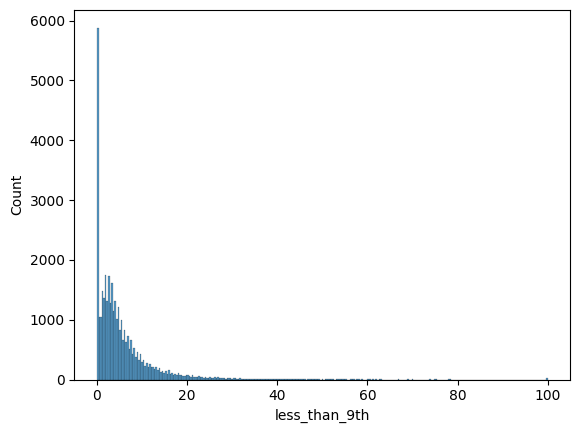

In [83]:
sns.histplot(data=clean_df,x="less_than_9th")    

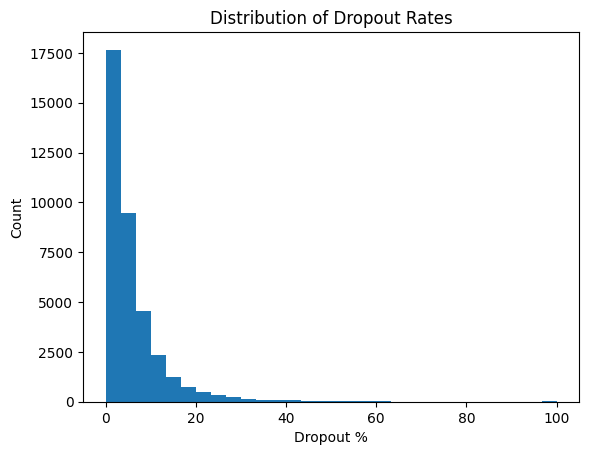

In [84]:
plt.figure()
plt.hist(clean_df["less_than_9th"], bins=30)
plt.title("Distribution of Dropout Rates")
plt.xlabel("Dropout %")
plt.ylabel("Count")
plt.show()

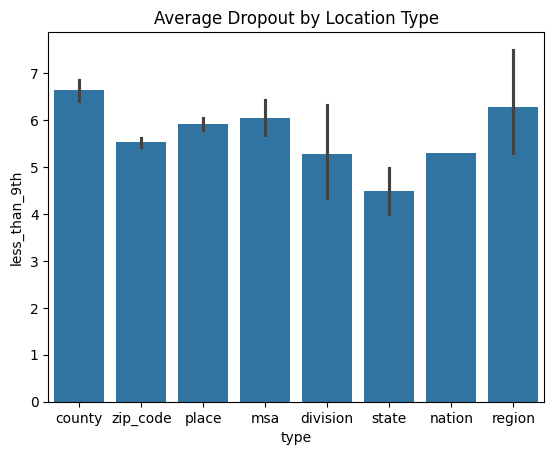

In [85]:
sns.barplot(data=clean_df, x="type", y="less_than_9th")
plt.title("Average Dropout by Location Type")
plt.show()

In [88]:
clean_df.sort_values("less_than_9th", ascending=False).head(40)

,name,type,year,variable,less_than_9th
15753,"Capron town, Oklahoma",place,2013,percent_less_than_9th_grade,100.00
29207,"Del Mar Heights CDP, Texas",place,2013,avg_male_female,100.00
29833,"Excello CDP, Missouri",place,2013,avg_male_female,100.00
15503,82936 ZIP Code,zip_code,2013,percent_less_than_9th_grade,100.00
9473,29338 ZIP Code,zip_code,2013,percent_less_than_9th_grade,100.00
32458,"Los Angeles CDP, Texas",place,2013,avg_male_female,100.00
30292,"Garceno CDP, Texas",place,2013,avg_male_female,100.00
37334,"Whitmer CDP, West Virginia",place,2013,avg_male_female,100.00
32464,"Los Fresnos CDP, Texas",place,2013,avg_male_female,100.00
19766,35074 ZIP Code,zip_code,2013,avg_male_female,100.00


In [89]:
clean_df[clean_df["less_than_9th"] == 100].head()

,name,type,year,variable,less_than_9th
133,"Kohatk CDP, Arizona",place,2013,percent_less_than_9th_grade,100.0
4057,"Olmito and Olmito CDP, Texas",place,2013,percent_less_than_9th_grade,100.0
9473,29338 ZIP Code,zip_code,2013,percent_less_than_9th_grade,100.0
10337,"Banks CDP, Idaho",place,2013,percent_less_than_9th_grade,100.0
11261,12530 ZIP Code,zip_code,2013,percent_less_than_9th_grade,100.0


I removed extreme outliers (e.g., 100% dropout rates) to ensure realistic and reliable analysis.”

In [90]:
clean_df = clean_df[clean_df["less_than_9th"] < 75]

In [91]:
clean_df

,name,type,year,variable,less_than_9th
0,"Adjuntas Municipio, Puerto Rico",county,2013,percent_less_than_9th_grade,26.80
1,78221 ZIP Code,zip_code,2013,percent_less_than_9th_grade,17.00
2,"Gassaway town, West Virginia",place,2013,percent_less_than_9th_grade,9.50
3,48848 ZIP Code,zip_code,2013,percent_less_than_9th_grade,1.70
4,76888 ZIP Code,zip_code,2013,percent_less_than_9th_grade,0.00
...,...,...,...,...,...
37655,"Zolfo Springs town, Florida",place,2013,avg_male_female,35.95
37656,"Zortman CDP, Montana",place,2013,avg_male_female,0.00
37657,"Zuehl CDP, Texas",place,2013,avg_male_female,1.90
37658,"Zumbro Falls city, Minnesota",place,2013,avg_male_female,0.00


In [93]:
clean_df[clean_df["less_than_9th"] == 0]

,name,type,year,variable,less_than_9th
4,76888 ZIP Code,zip_code,2013,percent_less_than_9th_grade,0.0
5,"Glenwood CDP, New Mexico",place,2013,percent_less_than_9th_grade,0.0
22,20617 ZIP Code,zip_code,2013,percent_less_than_9th_grade,0.0
24,"Fulford CDP, Colorado",place,2013,percent_less_than_9th_grade,0.0
33,"Portersville borough, Pennsylvania",place,2013,percent_less_than_9th_grade,0.0
...,...,...,...,...,...
37644,"Zarate CDP, Texas",place,2013,avg_male_female,0.0
37652,"Zinc town, Arkansas",place,2013,avg_male_female,0.0
37653,"Zion CDP, Pennsylvania",place,2013,avg_male_female,0.0
37656,"Zortman CDP, Montana",place,2013,avg_male_female,0.0


In [94]:
clean_df = clean_df[clean_df["less_than_9th"] > 0]

In [95]:
clean_df

,name,type,year,variable,less_than_9th
0,"Adjuntas Municipio, Puerto Rico",county,2013,percent_less_than_9th_grade,26.80
1,78221 ZIP Code,zip_code,2013,percent_less_than_9th_grade,17.00
2,"Gassaway town, West Virginia",place,2013,percent_less_than_9th_grade,9.50
3,48848 ZIP Code,zip_code,2013,percent_less_than_9th_grade,1.70
6,43504 ZIP Code,zip_code,2013,percent_less_than_9th_grade,0.50
...,...,...,...,...,...
37651,"Zilwaukee city, Michigan",place,2013,avg_male_female,0.80
37654,"Zionsville town, Indiana",place,2013,avg_male_female,0.50
37655,"Zolfo Springs town, Florida",place,2013,avg_male_female,35.95
37657,"Zuehl CDP, Texas",place,2013,avg_male_female,1.90


<Axes: xlabel='less_than_9th', ylabel='Count'>

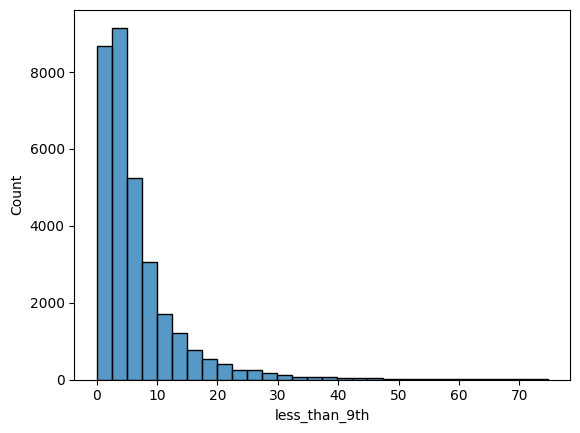

In [96]:
sns.histplot(clean_df['less_than_9th'], bins=30)

In [97]:
clean_df["less_than_9th"].describe()

count    32039.000000
mean         6.655686
std          7.148230
min          0.050000
25%          2.400000
50%          4.500000
75%          8.200000
max         74.700000
Name: less_than_9th, dtype: float64

In [98]:
clean_df.groupby("type")["less_than_9th"].mean().sort_values(ascending=False)

type
place       7.074320
county      6.644877
zip_code    6.330143
region      6.266667
msa         6.033366
nation      5.300000
division    5.278571
state       4.496552
Name: less_than_9th, dtype: float64

In [99]:
top15 = clean_df.sort_values("less_than_9th", ascending=False).head(15)
top15[["name", "type", "less_than_9th"]]

,name,type,less_than_9th
36279,"Tanquecitos South Acres CDP, Texas",place,74.70
34785,"Ranchitos East CDP, Texas",place,73.90
26,29683 ZIP Code,zip_code,73.80
35091,"Rodriguez Camp CDP, California",place,73.50
15208,40816 ZIP Code,zip_code,73.10
10036,"North Escobares CDP, Texas",place,72.90
35379,"Santa Cruz CDP, Texas",place,71.60
35320,"San Juan CDP, Texas",place,70.95
36894,"Wall Lane CDP, Arizona",place,70.10
25311,83602 ZIP Code,zip_code,70.00


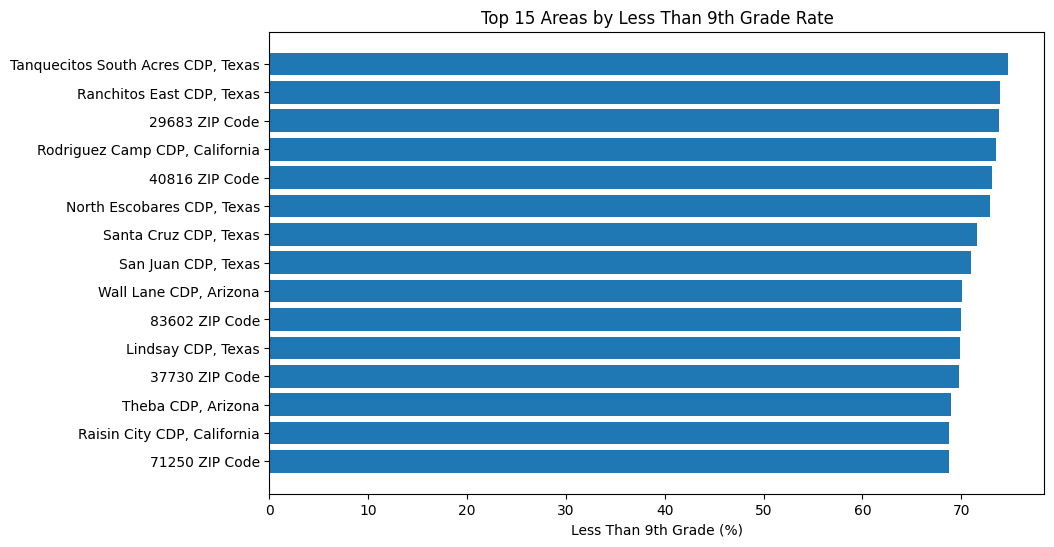

In [100]:
plt.figure(figsize=(10,6))
plt.barh(top15["name"], top15["less_than_9th"])
plt.gca().invert_yaxis()
plt.title("Top 15 Areas by Less Than 9th Grade Rate")
plt.xlabel("Less Than 9th Grade (%)")
plt.show()

After cleaning inconsistent education records, the analysis shows that most U.S. locations have low less-than-9th-grade rates, but a small group of areas show much higher educational risk. ZIP-code level data reveals stronger local variation, making it useful for identifying high-risk communities more precisely